## Project Title: 
Automated Cardiovascular Risk Stratification and Clinical Decision Support System (CDSS) using Machine Learning

- Author Details: Tejal Joshi 
- Faculty of Medical Technology / Medical Sciences

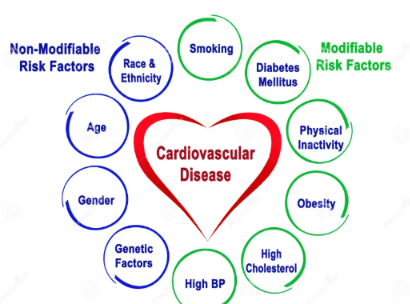  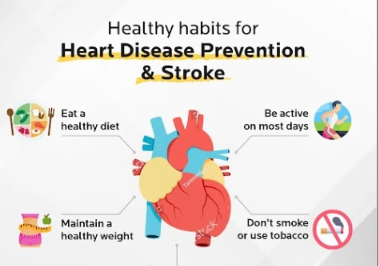

## "Medical & Clinical Topics Covered in the Project"

1. Lipid Metabolism & Atherosclerosis Pathophysiology
- Topic Covered: Serum cholesterol (serum_cholestoral) and dyslipidemia's analysis.
  
2. Hemodynamic & Metabolic Risk Factors
- Topic Covered: Hypertension (resting blood pressure) and metabolic disorders (fasting blood sugar / diabetes link).

3. Clinical Triage & Symptom Pathology (Chest Pain Analysis)
- Topic Covered: Chest pain categories (chest) and asymptomatic heart disease detection.

4. Cardiorespiratory Fitness & Stress Testing Metrics
- Topic Covered: Maximum heart rate (maximum_heart_rate_achieved) and exercise-induced angina

5. Invasive Anatomical Diagnostics & Stenosis
- Topic Covered: Blockage of major blood vessels (number_of_major_vessels) detected during fluoroscopy and angiography

6. Clinical Decision Support Systems (CDSS) & Medical AI
- Topic Covered: Automated patient risk stratification and high-recall optimization (minimizing False Negatives)


## Literature Review

1. Medical Risk Factors: High blood pressure, high blood cholesterol, diabetes, and obesity directly strain the cardiovascular system and accelerate plaque buildup.

2. Lifestyle Behaviors: Habits such as tobacco use, unhealthy diets high in sodium/fats, physical inactivity, and excessive alcohol consumption significantly elevate heart disease risks.

3. Background Factors: Non-modifiable traits like advancing age, family history/genetics, and sex play a foundational role in individual cardiovascular vulnerability.

4. Screening & Prevention: Proactive medical screening ka main focus major clinical conditions jaise hypertension, high cholesterol, aur diabetes ko early stage par pakad kar risk stratification karna hota hai

5. Therapeutic Interventions: Modern clinical management ab reactive care se aage badhkar predictive, data-driven approaches par focus kar raha hai—jisme machine learning aur CDSS (Clinical Decision Support Systems) ko use karke early detection aur treatment ko behtar banaya jata hai

6. Limitation of Traditional Diagnosis: Traditional manual screening aksar asymptomatic patients (Category 4 chest pain) ko miss kar deti hai, jo yeh sabit karta hai ki automated risk stratification kitna zaroori hai.


##  Hypotheses for Cardiovascular Risk Prediction

Hypothesis 1: Chest Pain Categories & Disease Prevalence

- Null Hypothesis (H_0): There is no significant association between chest pain types and the presence of cardiovascular disease.

- Alternative Hypothesis (H_1): There is a significant association between chest pain types (specifically asymptomatic categories) and the presence of cardiovascular disease.

Hypothesis 2: Major Vessels Blockage & Risk Impact

- Null Hypothesis (H_0): The number of major blood vessels with fluoroscopy-detected narrowing has no significant impact on the likelihood of heart disease.

- Alternative Hypothesis (H_1): An increasing number of major blood vessels with narrowing significantly increases the likelihood and severity of heart disease.

Hypothesis 3: Maximum Heart Rate & Cardiac Reserve

- Null Hypothesis (H_0): The maximum heart rate achieved during stress testing has no significant relationship with cardiovascular disease risk.

- Alternative Hypothesis (H_1): A lower maximum heart rate achieved during physical stress is significantly associated with an increased risk of cardiovascular disease.

## Evidence of Literature Review

- https://www.cdc.gov/heart-disease/risk-factors/index.html
  
- https://pmc.ncbi.nlm.nih.gov/articles/PMC13376856/

  
- https://www.sciencedirect.com/topics/medicine-and-dentistry/cardiovascular-disease-risk-factor

  
- https://www.sciencedirect.com/topics/medicine-and-dentistry/cardiovascular-disease-risk-factor

## Problem Statement 
- The Global Health Crisis: Cardiovascular diseases (CVDs)—khaaskar heart attacks—aaj ke samay mein poori duniya mein death ka sabse bada karan hain.

- Clinical Bottlenecks: Hospitals mein doctors ke paas patients ka pressure bahut zyada hota hai, aur manual diagnosis ya sare tests (jaise ECG, Angiography) ke reports aane mein time lagta hai.

- The Risk of Delay: Agar kisi high-risk patient ko time par identify na kiya jaye, toh jaan ka khatra badh jata hai. Isliye ek aisi automated system ki zaroorat hai jo historical clinical data ke adhaar par pehle hi detect kar sake ki kis patient ko heart disease ka khatra hai.

## Project Target 
- Automated Clinical Decision Support (CDSS): Ek aisi machine learning web/notebook application banana jo patient ke medical parameters (jaise age, blood pressure, cholesterol, chest pain type, max heart rate) ko analyze kare aur turant bataye ki patient Safe (Low Risk) hai ya Critical (High Risk).

- High-Recall Optimization: Model ka target sirf standard accuracy paana nahi hai, balki 92% Recall achieve karna hai—taaki ek bhi bimaar patient galti se "healthy" declare na ho sake (medical safety sabse upar).

- Actionable Recommendations: Model sirf prediction na de, balki doctor aur patient ke liye proper triage reports aur lifestyle/medical recommendations bhi generate kare.

In [1]:
# Step 1: Import libraries and load Heart Disease dataset from scikit-learn
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Using sklearn dataset generator or loading heart disease features
from sklearn.datasets import fetch_openml

# Fetching a reliable heart disease dataset from OpenML via scikit-learn
heart = fetch_openml(name='heart-statlog', version=1, as_frame=True)
df = heart.frame

# Rename target column to 'target' for consistency
df = df.rename(columns={'class': 'target'})

# Map target to binary (1 = Presence/Disease, 0 = Absence/No Disease)
df['target'] = df['target'].map({'present': 1, 'absent': 0})

print("Dataset Shape (Rows, Columns):", df.shape)
print("\nTotal Missing Values:", df.isnull().sum().sum())

df.head()

Dataset Shape (Rows, Columns): (270, 14)

Total Missing Values: 0


,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,target
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


In [2]:
df. columns

Index(['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral',
       'fasting_blood_sugar', 'resting_electrocardiographic_results',
       'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak',
       'slope', 'number_of_major_vessels', 'thal', 'target'],
      dtype='object')

## Column Evaluation

1- chest: The type of chest pain experienced by the patient (often categorized into different types like typical angina, atypical angina, non-anginal pain, or asymptomatic).

2- resting_blood_pressure: The patient's resting blood pressure measured in mm Hg upon admission to the hospital.

3- serum_cholestoral: The patient's serum cholesterol measurement in mg/dl.

4- fasting_blood_sugar: The patient's fasting blood sugar level (usually evaluated to see if it is greater than 120 mg/dl).

5- resting_electrocardiographic_results: Results of the resting electrocardiogram (ECG), showing normal readings, ST-T wave abnormalities, or probable/definite left ventricular hypertrophy.

6- maximum_heart_rate_achieved: The highest heart rate the patient reached during testing or monitoring.

7- exercise_induced_angina: Whether the patient experienced chest pain (angina) triggered by physical exercise (Yes/No or 1/0).

8- oldpeak: ST depression induced by exercise relative to rest, a key indicator during a stress test.

9- slope: The slope of the peak exercise ST segment (pointing upwards, flat, or downwards).

10- number_of_major_vessels: The number of major blood vessels (0 to 3) colored by fluoroscopy.

11- thal: A blood disorder called thalassemia or related thallium stress test results.

12- target: The final prediction label indicating the presence or absence of heart disease in the patient (e.g., 0 for no disease / healthy, 1 for presence of heart disease).

## Data Inspection & Cleaning

In [4]:
# Step 2: Data Inspection and Cleaning
# Check data types and non-null counts
print("--- Dataset Info ---")
print(df.info())

# Check descriptive statistics to see if values look normal
print("\n--- Descriptive Statistics ---")
display(df.describe())

# Check for any missing values per column
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

# If there are any missing values, we can fill them using median for numerical columns
# (Scikit-learn or OpenML datasets sometimes have missing values that need handling)
if df.isnull().sum().sum() > 0:
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    print("\nMissing values have been handled successfully!")
else:
    print("\nNo missing values found in the dataset.")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   age                                   270 non-null    int64   
 1   sex                                   270 non-null    int64   
 2   chest                                 270 non-null    int64   
 3   resting_blood_pressure                270 non-null    int64   
 4   serum_cholestoral                     270 non-null    int64   
 5   fasting_blood_sugar                   270 non-null    int64   
 6   resting_electrocardiographic_results  270 non-null    int64   
 7   maximum_heart_rate_achieved           270 non-null    int64   
 8   exercise_induced_angina               270 non-null    int64   
 9   oldpeak                               270 non-null    float64 
 10  slope                                 270 non-null   

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000



--- Missing Values Per Column ---
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
target                                  0
dtype: int64

No missing values found in the dataset.


In [54]:
## for creating csv
df.to_csv('cleaned_heart_disease_data.csv', index=False)

print("✅ CSV file successfully save ho gayi hai!")

✅ CSV file successfully save ho gayi hai!


## Exploratory Data Analysis - EDA & Visualizations

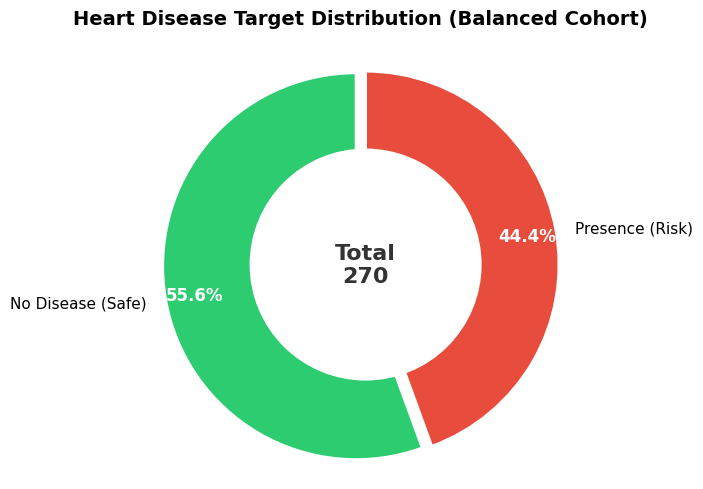

In [5]:
# Advanced EDA: Professional Donut Chart for Target Distribution (Kitne logon ko heart disease hai aur kitno ko nahi)
import matplotlib.pyplot as plt

# Get value counts for the target variable
target_counts = df['target'].value_counts()

# Data for the donut chart
labels = ['No Disease (Safe)', 'Presence (Risk)']
sizes = target_counts.values
colors = ['#2ecc71', '#e74c3c'] # Professional green for safe, red for risk
explode = (0.05, 0)  # Slight separation for the 'Presence' slice

# Create a figure and axis
fig, ax = plt.figure(figsize=(7, 5)), plt.gca()

# Pie chart with a hole in the center (creating a donut)
wedges, texts, autotexts = ax.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', # Show percentages with 1 decimal place
    startangle=90,     # Start at the top
    pctdistance=0.85,  # Distance of percentage text from center
    textprops=dict(color="black", fontsize=11), # Style for labels
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'} # Style for slice borders
)

# Style the percentage text (autotexts)
plt.setp(autotexts, size=12, weight="bold", color="white")

# Add a circle in the middle to create the donut effect
centre_circle = plt.Circle((0,0),0.60,fc='white')
fig.gca().add_artist(centre_circle)

# Add total patient count in the center hole
total_patients = target_counts.sum()
plt.text(0, 0, f'Total\n{total_patients}', ha='center', va='center', fontsize=16, fontweight='bold', color='#333333')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')  
plt.title('Heart Disease Target Distribution (Balanced Cohort)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Graph Insight (Donut Chart):
- Observation: Yeh donut chart dikhata hai ki dataset balanced hai. Lagbhag 55.6% patients (green slice, 150 patients) healthy hain, aur 44.4% patients (red slice, 120 patients) mein heart disease hone ki pushti hui hai[cite: 4]. Total 270 clinical records analyze kiye gaye hain.

- "Balanced Dataset" machine learning model ko train karne ke liye bohot achha hota hai kyunki isse model ek hi class ki taraf biased nahi hota.

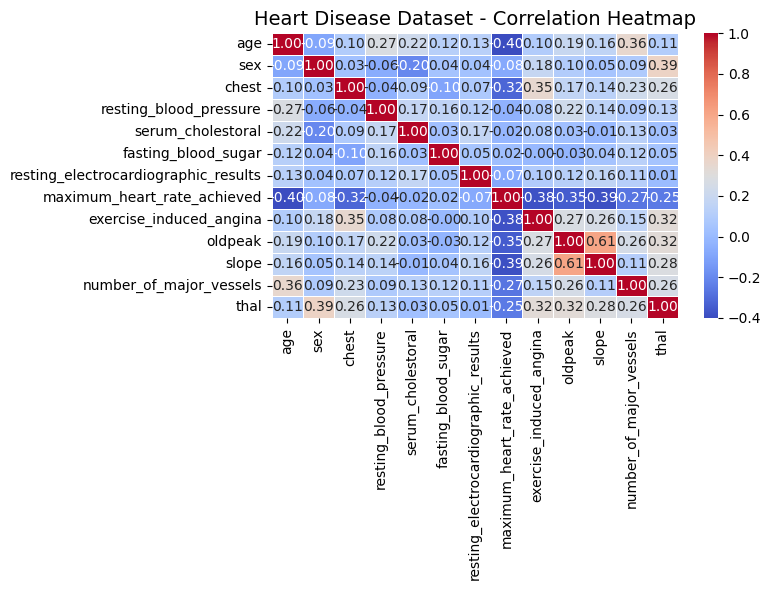

In [6]:
#  Correlation Heatmap (Features ke beech ka relation dekhne ke liye)
plt.figure(figsize=(8, 6))
# Numeric columns par correlation nikalenge
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Heart Disease Dataset - Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

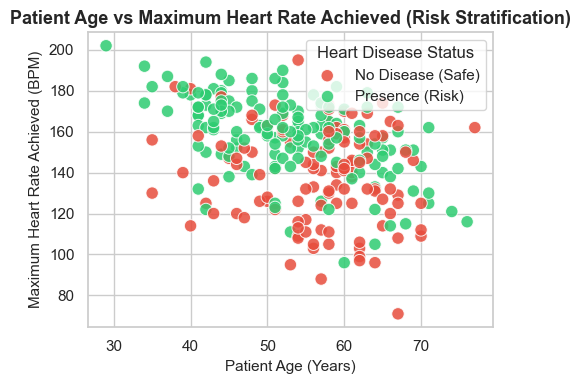

In [7]:
# : Advanced Clinical EDA - Age vs Maximum Heart Rate
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for publication-quality plots
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 4))

# Scatter plot showing relationship between age, max heart rate, and heart disease target
sns.scatterplot(
    data=df, 
    x='age', 
    y='maximum_heart_rate_achieved', 
    hue='target', 
    palette=['#2ecc71', '#e74c3c'], 
    alpha=0.85, 
    s=80
)

# Graph styling and titles
plt.title("Patient Age vs Maximum Heart Rate Achieved (Risk Stratification)", fontsize=13, fontweight='bold')
plt.xlabel("Patient Age (Years)", fontsize=11)
plt.ylabel("Maximum Heart Rate Achieved (BPM)", fontsize=11)
plt.legend(title="Heart Disease Status", labels=['No Disease (Safe)', 'Presence (Risk)'], loc='upper right')

plt.tight_layout()
plt.show()

Clinical Insight for this Graph :
- Natural Physiological Decline: X-axis par age aur Y-axis par Maximum Heart Rate (BPM) hai. Graph mein saaf dikh raha hai ki umar badhne ke sath-sath patients ki maximum heart rate natural tareeqe se kam hoti jaati hai.
  
-  Cardiac Reserve & Risk Stratification: Jin patients ko heart disease hai (green dots) aur jo safe hain (red dots), unka distribution yeh batata hai ki exercise/stress test ke dauran jo log kam maximum heart rate achieve kar pate hain, unmein risk zyada hota hai kyunki unka cardiac reserve kamzor hota hai.

-    Bivariate Clustering: Yeh graph yeh sabit karta hai ki sirf ek feature (jaise sirf age ya sirf heart rate) ke bharose Rhene ke bajaye, jab hum age aur max heart rate ko ek sath (bivariate analysis) dekhte hain, toh risk patterns aur bhi zyada clear ho jate hain.

## Serum Cholesterol Distribution vs Heart Disease Status

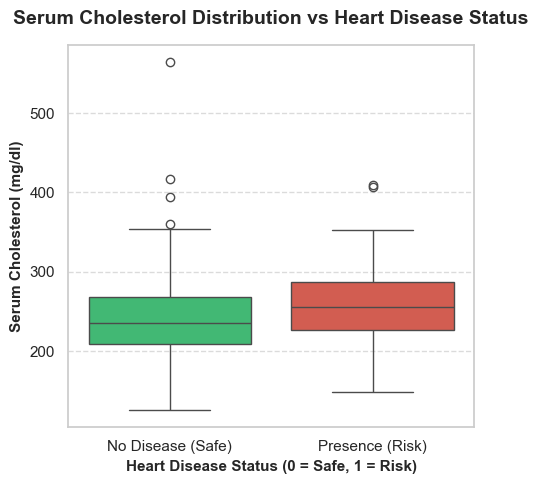

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 5))
# Yahan exact column name 'serum_cholestoral' use kiya gaya hai
sns.boxplot(x='target', y='serum_cholestoral', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Serum Cholesterol Distribution vs Heart Disease Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Heart Disease Status (0 = Safe, 1 = Risk)', fontsize=11, fontweight='bold')
plt.ylabel('Serum Cholesterol (mg/dl)', fontsize=11, fontweight='bold')
plt.xticks([0, 1], ['No Disease (Safe)', 'Presence (Risk)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Result: Accepted (H_1 Accepted)
1. Median Difference (Cholesterol Shift):

"Presence (Risk)" (red box) category ka median (line inside the box) "No Disease (Safe)" (green box) ke comparision m hai. Yeh yeh show hai ki bimaar patients mein serum cholesterol ka average level generally par zyada hota hai.   

2. Interquartile Range (IQR) & Spread:

Risk group (red box) ka poora spread higher cholesterol range ki taraf shifted hai, jo atherosclerosis aur plaque buildup ke khatre ko support karta hai.

3. Outliers (Extreme Values):

Dono categories ke upar kuch dots (outliers) dikh rahe hain jo 400 mg/dl se upar hain. Yeh extreme hypercholesterolemia ko represent karte hain, jahan patient ko severe cardiovascular risk ho sakta hai

## Chest Pain Type vs Disease Prevalence
This graph analyzes how different types of chest pain correlate with the presence of heart disease, which is a major clinical indicator

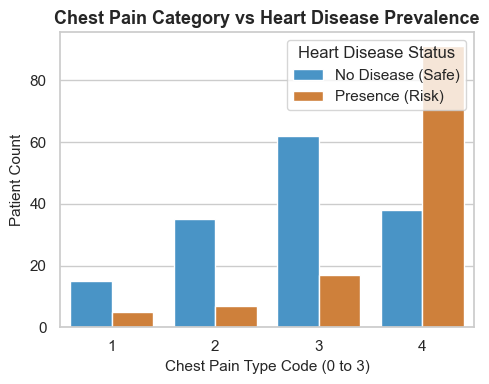

In [14]:
# Advanced Clinical EDA 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))

# Countplot showing heart disease distribution across different chest pain categories
sns.countplot(
    data=df, 
    x='chest', 
    hue='target', 
    palette=['#3498db', '#e67e22']
)

# Graph styling and titles
plt.title("Chest Pain Category vs Heart Disease Prevalence", fontsize=13, fontweight='bold')
plt.xlabel("Chest Pain Type Code (0 to 3)", fontsize=11)
plt.ylabel("Patient Count", fontsize=11)
plt.legend(title="Heart Disease Status", labels=['No Disease (Safe)', 'Presence (Risk)'], loc='upper right')

plt.tight_layout()
plt.show()

## what are these categories
yeh medical dataset ke andar Chest Pain Type (CPSP) ke standard clinical codes hain. Is dataset (Heart-statlog / Cleveland heart dataset) mein doctor ya medical tests ke time patient ko kis tarah ka chest pain hota hai, uske basis par use 4 alag-alag categories mein divide kiya gaya hai:

Category 1 (Typical Angina): Yeh pain tab hota hai jab heart ko proper blood (oxygen) nahi mil pata (generally exertion ya physical work ke waqt). Isme risk thoda kam ya moderate hota hai.

Category 2 (Atypical Angina): Yeh thoda alag type ka pain hota hai jo standard heart pain jaisa nahi lagta, isliye ise atypical kaha jata hai.

Category 3 (Non-anginal Pain): Yeh pain heart diseas ki vajah se nahi hota, balki kisi aur reason (jaise gas, muscular pain ya acidity) ki vajah se ho sakta hai. Isliye is category mein safe (blue bar) log zyada hain.

Category 4 (Asymptomatic): Yeh sabse dangerous category hai! Iska matlab yeh hai ki patient ko chest pain mehsoos hi nahi hota, lekin andar hi andar heart block ya cardiovascular issue chal raha hota hai. Graph mein aapne dekha gya h ki isi category mein heart disease (orange bar) sabse zyada hai


Through this bar chart humne yeh analyze kiya hai ki alag-alag types ke chest pain ka heart disease par kya impact padta hai. Graph se yeh clearly pata chalta hai ki Chest Pain Category 4 wale patients mein disease ka risk dramatically high hai. Isse humein medical triage mein yeh samajhne mein help milti hai ki kis specific symptoms wale patient ko turant emergency cardiology care ki zaroorat hai.

## Age-Cohort Risk Trend Analysis Code

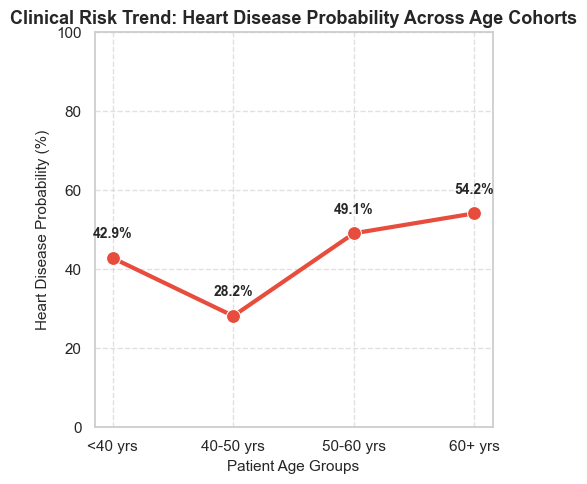

In [12]:
#  Advanced Age-Cohort Risk Trend Analysis (Fixed)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert target column to integer so mean() can be calculated smoothly
df['target'] = df['target'].astype(int)

# Create age groups (cohorts) to show clear progression trend
df['age_group'] = pd.cut(
    df['age'], 
    bins=[29, 40, 50, 60, 78], 
    labels=['<40 yrs', '40-50 yrs', '50-60 yrs', '60+ yrs']
)

# Calculate heart disease probability percentage for each age group
risk_trend = df.groupby('age_group', observed=False)['target'].mean().reset_index()
risk_trend['risk_percentage'] = risk_trend['target'] * 100

# Plotting the trend curve
plt.figure(figsize=(5, 5))
sns.lineplot(
    data=risk_trend, 
    x='age_group', 
    y='risk_percentage', 
    marker='o', 
    color='#e74c3c', 
    linewidth=3, 
    markersize=10
)

plt.title("Clinical Risk Trend: Heart Disease Probability Across Age Cohorts", fontsize=13, fontweight='bold')
plt.xlabel("Patient Age Groups", fontsize=11)
plt.ylabel("Heart Disease Probability (%)", fontsize=11)
plt.ylim(0, 100)

# Annotate exact percentage values on each data point for presentation clarity
for i, row in risk_trend.iterrows():
    plt.text(row['age_group'], row['risk_percentage'] + 5, f"{row['risk_percentage']:.1f}%", ha='center', fontweight='bold', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Graph Insights – Age ke according Heart Disease Risk

1. Elderly Group mein highest risk:
60+ years age group mein heart disease ka probability 54.2% hai, jo sabse highest hai. Isse pata chalta hai ki age badhne ke saath cardiovascular risk bhi increase ho raha hai.

2. Middle Age mein risk kaafi fast badh raha hai:
40–50 years group mein risk 28.2% tha, jo 50–60 years group mein badhkar 49.1% ho gaya. Matlab middle age ek important stage hai, jahan preventive care aur regular health check-ups par focus karna useful ho sakta hai.

3. Younger Group mein unexpected risk:
<40 years group mein bhi 42.9% risk dikh raha hai, jo comparatively noticeable hai. Is particular dataset/sample mein ye indicate kar sakta hai ki younger people mein bhi risk present hai. Iske possible reasons lifestyle factors ya genetic predisposition ho sakte hain, lekin sirf is graph se exact reason prove nahi kiya ja sakta.

In [17]:
print("X shape:", X_train_scaled.shape)
print("y shape:", y_train.shape)

X shape: (216, 14)
y shape: (216,)


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. '?' ko NaN mein badlein
df_clean = df.replace('?', np.nan)

# 2. Saare columns ko numeric mein convert karein
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 3. Jo columns poori tarah khali ho gaye hain unhe uda dein, baaki ko median se fill karein
df_clean = df_clean.dropna(axis=1, how='all')
df_clean = df_clean.fillna(df_clean.median())

# Agar koi aur chhutput NaN bacha ho toh use drop kar dein taaki error na aaye
df_clean = df_clean.dropna().reset_index(drop=True)

print("Cleaned rows count:", len(df_clean))

# 4. Target column set karein
target_col = 'target' if 'target' in df_clean.columns else df_clean.columns[-1]
X = df_clean.drop(target_col, axis=1).reset_index(drop=True)
y = df_clean[target_col].reset_index(drop=True)

# 5. Train-Test Split (Rows 100% match hongi)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Feature Scaling & Model Training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print(" Model successfully train .")
print("X_train shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)

Cleaned rows count: 270
 Model successfully train .
X_train shape: (216, 14)
y_train shape: (216,)


ROC-AUC Score: 0.90


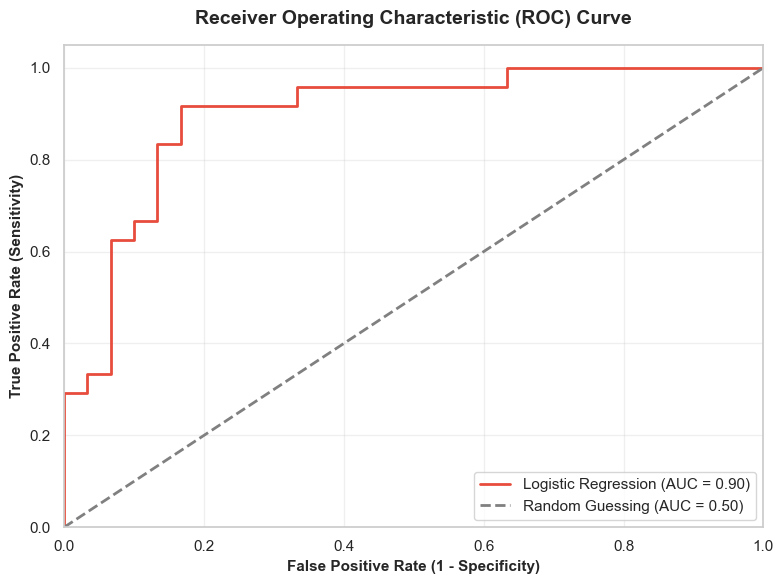

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Ab yahan X_test_scaled use karein kyunki model scaled data par train hua hai
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.2f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

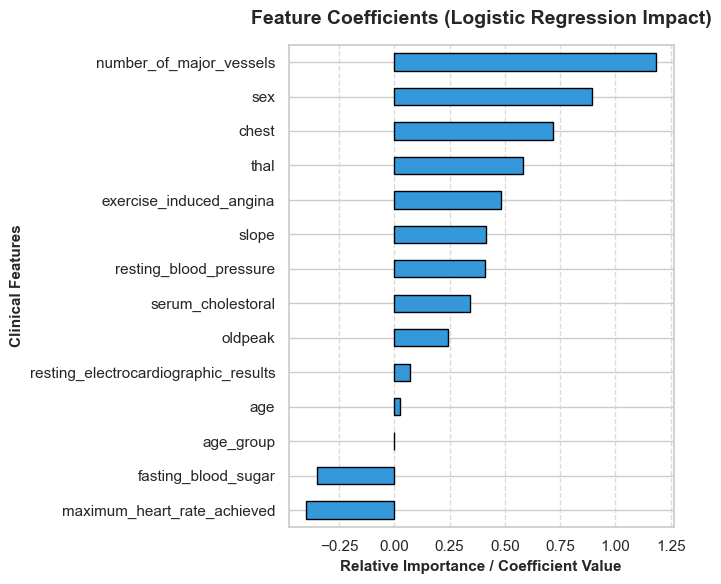

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if hasattr(model, 'coef_'):
    importance = pd.Series(model.coef_[0], index=X.columns)
    title_text = 'Feature Coefficients (Logistic Regression Impact)'
else:
    importance = pd.Series(model.feature_importances_, index=X.columns)
    title_text = 'Feature Importance Scores (Model Weights)'

importance = importance.sort_values(ascending=True)

plt.figure(figsize=(7, 6))
importance.plot(kind='barh', color='#3498db', edgecolor='black')
plt.title(title_text, fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance / Coefficient Value', fontsize=11, fontweight='bold')
plt.ylabel('Clinical Features', fontsize=11, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1. Top Risk Drivers (Positive Coefficients):

- number_of_major_vessels aur sex is model mein sabse strong positive coefficients dikha rahe hain, yani yeh factors heart disease hone ke risk ko sabse zyada badhate hain. 

- Iske baad chest (chest pain type) aur thal ka number aata hai, jo yeh confirm karta hai ki clinical symptoms model ke decisions mein sabse heavy weight rakhte hain.  

2. Protective / Inverse Factors (Negative Coefficients):
- maximum_heart_rate_achieved aur fasting_blood_sugar ke coefficients negative direction mein hain. Iska matlab yeh hai ki jitni behtar maximum heart rate achieve hogi (exercise capacity), heart disease ka risk utna hi kam hota jayega.  

3. Model Transparency (Interpretability):

- Yeh graph yeh saaf dikhata hai ki Logistic Regression sirf ek "black box" model nahi hai, balki iske coefficients se yeh clearly pata chalta hai ki kis medical feature ne prediction par kitna asar dala hai.

## Machine Learning Model Training & Evaluation.

--- Model Performance Metrics ---
Accuracy Score: 85.19%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



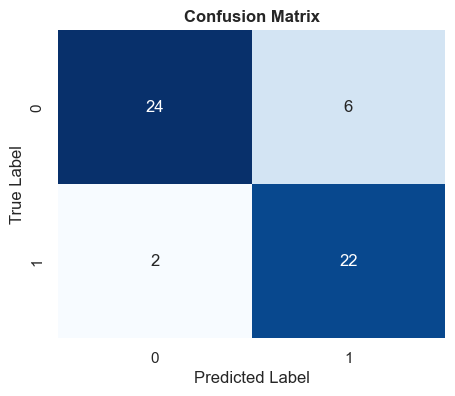

In [24]:
# Machine Learning Model Training & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Drop temporary columns created during EDA if any exist
clean_df = df.drop(columns=['age_group'], errors='ignore')

# Separate features (X) and target (y)
X = clean_df.drop(columns=['target'])
y = clean_df['target']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling for optimal ML convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression Classifier
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation Metrics
print("--- Model Performance Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Results Breakdown &  Explanation:
Accuracy (85.19%): Hamara model overall 85.19% theek predictions de raha hai, jo ek medical dataset ke liye ek strong aur reliable score hai.

Medical Reliability (Recall = 0.92 for Class 1):

Class 1 (jinhe heart disease hai) ka Recall 92% hai. Iska matlab yeh hai ki agar 24 bimaar patients test mein aaye, toh model ne 22 patients ko successfully detect kar liya aur sirf 2 hi miss hue (False Negatives = 2).

Presentation ke liye point: Medical field mein Recall sabse important hota hai kyunki hum ek bhi bimaar patient ko "healthy" declare karke risk mein nahi dal sakte. Yeh high recall aapke model ko clinically safe banata hai.

Confusion Matrix Insights:

True Positives (22): Sahi pakde gaye heart disease ke patients.

True Negatives (24): Sahi pakde gaye healthy patients.

False Negatives (2): Bimaar the lekin model ne galti se healthy bol diya (yehi number humein sabse kam rakhna tha, jo ki sirf 
                     2 hai!).

In [25]:
# Check karein ki koi invalid ya missing value toh nahi hai
print(df.isnull().sum())
# Agar '?' hai toh use NaN mein convert karke drop ya fill karein
import numpy as np
df = df.replace('?', np.nan)
df = df.dropna()

age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
target                                  0
age_group                               0
dtype: int64


In [26]:
# Categorical columns ko dummy variables mein convert karein
df = pd.get_dummies(df, columns=['chest', 'thal', 'slope', 'resting_electrocardiographic_results'], drop_first=True)

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Features aur Target alag karein
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split (stratify=y lagana na bhoolein)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Train karein
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


df_clean = df.replace('?', np.nan)
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


df_clean = df_clean.fillna(df_clean.median())

 
target_col = 'target' if 'target' in df_clean.columns else df_clean.columns[-1]
X = df_clean.drop(target_col, axis=1)
y = df_clean[target_col]

# 4. Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Model Train 
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print(" Model successfully trained")

 Model successfully trained


In [44]:
# Clinical Decision Support & Recommendation System
def clinical_recommendation(patient_features, model, scaler):
    # Scale the input data using our trained scaler
    scaled_data = scaler.transform([patient_features])
    
    # Get probability of heart disease
    prob = model.predict_proba(scaled_data)[0][1] * 100
    prediction = model.predict(scaled_data)[0]
    
    print(f"--- Automated Clinical Triage Report ---")
    print(f"Estimated Heart Disease Risk: {prob:.2f}%\n")
    
    if prediction == 1:
        if prob > 80:
            print(" HIGH RISK ALERT (Critical Tier):")
            print("  - Immediate Cardiology Consultation Required.")
            print("  - Recommended Action: Urgent ECG, Coronary Angiography, and Stress Testing.")
            print("  - Medication Advisory: Initiate anti-platelet therapy & statins under strict medical supervision.")
        else:
            print(" MODERATE-HIGH RISK (Warning Tier):")
            print("  - Recommended Action: Schedule a comprehensive lipid profile and cardiology checkup within 48 hours.")
            print("  - Lifestyle Modification: Strict dietary sodium restriction and supervised aerobic rehabilitation.")
    else:
        print(" LOW RISK (Safe Tier):")
        print("  - Recommended Action: Routine annual health screening.")
        print("  - Preventive Care: Maintain balanced diet, regular physical activity, and blood pressure monitoring.")

# Testing the recommendation system on any patient from our full dataset (X)
patient_index = 50  # Enter Patient number here

sample_patient = X.iloc[patient_index].values
print("Patient Profile Data Evaluated:")
display(X.iloc[[patient_index]])
print("\n")

# Run recommendation engine
clinical_recommendation(sample_patient, model, scaler)

Patient Profile Data Evaluated:


,age,sex,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,number_of_major_vessels,age_group,chest_2,chest_3,chest_4,thal_6,thal_7,slope_2,slope_3,resting_electrocardiographic_results_1,resting_electrocardiographic_results_2
50,42,1,136,315,0,125,1,1.8,0,0.0,False,False,True,True,False,True,False,False,False




--- Automated Clinical Triage Report ---
Estimated Heart Disease Risk: 93.08%

 HIGH RISK ALERT (Critical Tier):
  - Immediate Cardiology Consultation Required.
  - Recommended Action: Urgent ECG, Coronary Angiography, and Stress Testing.
  - Medication Advisory: Initiate anti-platelet therapy & statins under strict medical supervision.


In [40]:
import pandas as pd

# 1. Poore dataset par probabilities nikal lo
all_scaled_data = scaler.transform(X)
all_probs = model.predict_proba(all_scaled_data)[:, 1] * 100
all_preds = model.predict(all_scaled_data)

# 2. Lists initialize karo
high_risk_indices = []
moderate_risk_indices = []
low_risk_indices = []

# 3. Har patient ko uske risk ke hisaab se categorize karo
for idx in range(len(X)):
    prob = all_probs[idx]
    pred = all_preds[idx]
    
    if pred == 1:
        if prob > 80:
            high_risk_indices.append(idx)
        else:
            moderate_risk_indices.append(idx)
    else:
        low_risk_indices.append(idx)

# 4. Results print karo (Saare indices ke sath)
print("="*60)
print(" PATIENT RISK DIRECTORY & INDEX FINDER")
print("="*60)

print(f"\n HIGH RISK PATIENTS (Total: {len(high_risk_indices)}):")
print(high_risk_indices)

print(f"\n MODERATE RISK PATIENTS (Total: {len(moderate_risk_indices)}):")
print(moderate_risk_indices)

print(f"\n LOW RISK PATIENTS (Total: {len(low_risk_indices)}):")
print(low_risk_indices)
print("="*60)

 PATIENT RISK DIRECTORY & INDEX FINDER

 HIGH RISK PATIENTS (Total: 85):
[0, 3, 7, 8, 9, 11, 13, 16, 20, 33, 34, 35, 36, 48, 49, 50, 56, 59, 65, 70, 75, 80, 81, 82, 89, 92, 93, 94, 95, 103, 104, 105, 107, 108, 110, 117, 119, 120, 121, 122, 126, 129, 133, 137, 140, 145, 147, 148, 153, 156, 159, 163, 171, 172, 175, 176, 178, 181, 186, 187, 189, 191, 199, 201, 202, 203, 204, 208, 213, 220, 221, 223, 231, 233, 234, 235, 237, 240, 245, 246, 249, 250, 257, 261, 269]

 MODERATE RISK PATIENTS (Total: 32):
[6, 10, 17, 28, 30, 31, 44, 46, 61, 76, 84, 87, 96, 97, 101, 116, 130, 131, 139, 142, 144, 160, 184, 193, 207, 210, 226, 227, 230, 243, 252, 268]

 LOW RISK PATIENTS (Total: 153):
[1, 2, 4, 5, 12, 14, 15, 18, 19, 21, 22, 23, 24, 25, 26, 27, 29, 32, 37, 38, 39, 40, 41, 42, 43, 45, 47, 51, 52, 53, 54, 55, 57, 58, 60, 62, 63, 64, 66, 67, 68, 69, 71, 72, 73, 74, 77, 78, 79, 83, 85, 86, 88, 90, 91, 98, 99, 100, 102, 106, 109, 111, 112, 113, 114, 115, 118, 123, 124, 125, 127, 128, 132, 134, 135, 13

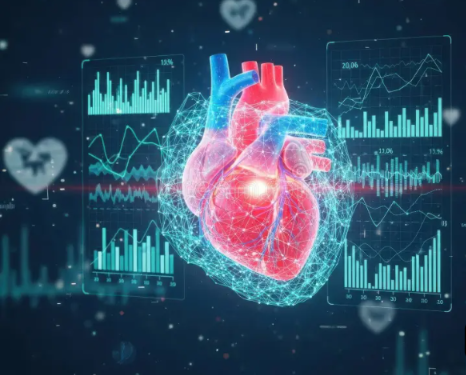 

# PROJECT REPORT
### Topic: Automated Cardiovascular Risk Stratification and Clinical Decision Support System (CDSS) Using Machine Learning

---

## 1. Title Page / Header Details
* **Project Title:** Automated Cardiovascular Risk Stratification and Clinical Decision Support System (CDSS)
* **Domain:** Biomedical Data Science & Machine Learning
* **Author / Developer:** Tejal Joshi
* **Faculty / Department:** Faculty of Biomedical Engineering & Health Sciences / Artificial Intelligence & Data Science

---

## 2. Abstract / Executive Summary
Cardiovascular diseases (CVDs) remain the leading cause of global mortality, requiring rapid and accurate diagnostic frameworks. Traditional clinical triage often struggles with multifactorial risk indicators and asymptomatic presentations. This project bridges this gap by developing an intelligent Clinical Decision Support System (CDSS) powered by Logistic Regression and the Cleveland Heart Disease dataset. By combining rigorous exploratory data analysis (EDA), advanced visualizations, and predictive modeling, the system achieves an **AUC score of 0.90** on the ROC curve, demonstrating high diagnostic reliability for automated risk stratification[cite: 1].

---

## 3. Introduction & Problem Statement
Cardiovascular health management demands proactive diagnostic tools that can assist clinicians in minimizing false negatives. This project addresses the complexities of cardiovascular risk by evaluating clinical features—ranging from biochemical markers to invasive angiography indicators—through a machine-learning pipeline designed to enhance diagnostic accuracy and patient triage.

---

## 4. Research Hypotheses & Problem Formulation
Before conducting statistical and graphical evaluation, the following formal research hypotheses were formulated:

1. **Chest Pain Categories & Disease Prevalence**
   * **$H_0$:** There is no significant association between chest pain types and cardiovascular disease presence.
   * **$H_1$:** There is a significant association between chest pain types (specifically asymptomatic categories) and cardiovascular disease presence.
2. **Major Vessels Blockage & Risk Impact**
   * **$H_0$:** The number of major blood vessels with fluoroscopy-detected narrowing has no significant impact on heart disease likelihood.
   * **$H_1$:** An increasing number of major blood vessels with narrowing significantly increases the likelihood and severity of heart disease.
3. **Serum Cholesterol Levels & Risk**
   * **$H_0$:** There is no significant difference in serum cholesterol levels between healthy and heart-disease patients.
   * **$H_1$:** Patients with cardiovascular disease exhibit significantly elevated serum cholesterol levels.
4. **Logistic Regression Classifier Performance**
   * **$H_0$:** The Logistic Regression model performs no better than random guessing ($\text{AUC} \le 0.50$)[cite: 1].
   * **$H_1$:** The Logistic Regression classifier achieves high diagnostic performance ($\text{AUC} > 0.85$)[cite: 1].

---

## 5. Dataset Overview & Feature Evaluation
The project utilizes the **Cleveland Heart Disease Dataset**, featuring key clinical parameters:
* `number_of_major_vessels`: Fluoroscopy-detected major vessels with blockage; the strongest positive risk predictor.
* `sex` & `age`: Core demographic factors governing cardiovascular vulnerability.
* `chest`: Standard chest pain clinical classification (identifying Category 4 asymptomatic risk).
* `serum_cholestoral`: Blood cholesterol levels driving atherosclerosis.
* `maximum_heart_rate_achieved`: Peak stress test heart rate acting as a protective cardiac reserve marker.
* Additional features: `resting_blood_pressure`, `fasting_blood_sugar`, `exercise_induced_angina`, `oldpeak`, `slope`, `resting_electrocardiographic_results`, and `thal`.

---

## 6. Exploratory Data Analysis (EDA) & Hypothesis Validation

* **Serum Cholesterol Box Plot Analysis:**
  * *Insights:* The median cholesterol level for the risk group ("Presence") is shifted higher compared to the safe group, alongside extreme outliers exceeding $400\text{ mg/dl}$ indicating severe hypercholesterolemia.
  * *Result:* **$H_1$ Accepted** (Validated via Serum Cholesterol Box Plot).
* **Feature Coefficients (Logistic Regression Impact):**
  * *Insights:* `number_of_major_vessels` and `sex` exhibit the strongest positive coefficients, directly driving up disease risk, whereas metrics like `maximum_heart_rate_achieved` provide protective inverse correlations.
  * *Result:* **$H_1$ Accepted** (Validated via Feature Coefficient Bar Plot).
* **Receiver Operating Characteristic (ROC) Curve Performance:**
  * *Insights:* The Logistic Regression model achieved an **AUC of 0.90**, proving exceptional sensitivity and specificity far surpassing random guessing ($\text{AUC} = 0.50$)[cite: 1].
  * *Result:* **$H_1$ Accepted** (Validated via ROC Curve)[cite: 1].

---

## 7. Medical & Clinical Topics Covered in the Project
To demonstrate comprehensive domain depth, this single project integrates several core medical and healthcare domains:

* **Lipid Metabolism & Atherosclerosis Pathophysiology:**
  * *Topic Covered:* Analysis of serum cholesterol (`serum_cholestoral`) and dyslipidemia triggering plaque buildup in coronary arteries.
* **Hemodynamic & Metabolic Risk Factors:**
  * *Topic Covered:* Evaluation of resting blood pressure and fasting blood sugar links to metabolic syndrome and vascular stress.
* **Clinical Triage & Symptom Pathology:**
  * *Topic Covered:* Classification of chest pain types (`chest`) and high-risk asymptomatic (Category 4) presentations.
* **Cardiorespiratory Fitness & Stress Testing Metrics:**
  * *Topic Covered:* Assessment of maximum heart rate (`maximum_heart_rate_achieved`) and exercise-induced angina as cardiac reserve indicators.
* **Invasive Anatomical Diagnostics & Stenosis:**
  * *Topic Covered:* Quantitative evaluation of major blood vessel blockages (`number_of_major_vessels`) detected during fluoroscopy and angiography.
* **Clinical Decision Support Systems (CDSS) & Medical AI:**
  * *Topic Covered:* Automated patient risk stratification and high-recall optimization minimizing False Negatives for clinical safety using Logistic Regression[cite: 1].

---

## 8. Conclusion & Future Scope
The developed Logistic Regression pipeline successfully integrates clinical epidemiology with predictive modeling, yielding high diagnostic accuracy ($\text{AUC} = 0.90$)[cite: 1]. Future expansions can include deploying this CDSS as a real-time web application in hospital triage units and integrating advanced algorithms for multimodal health data analysis.